## Model 1: Logistic Regression (Baseline)

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

### Load data & define features

In [24]:
# Fresh start from original data
df_raw = pd.read_csv("dropout_data.csv")
df_raw = df_raw[df_raw["State/UT"] != "India"].reset_index(drop=True)

# Rename columns cleanly
df_raw.columns = [
    "State",
    "Primary_1920",
    "Primary_2021",
    "Primary_2122",
    "UpperPrimary_1920",
    "UpperPrimary_2021",
    "UpperPrimary_2122",
    "Secondary_1920",
    "Secondary_2021",
    "Secondary_2122",
]

# ← ADD THIS: fill missing values with column median
df_raw = df_raw.fillna(df_raw.median(numeric_only=True))

# Features: Primary + Upper Primary dropout rates across years
X = df_raw[
    [
        "Primary_1920",
        "Primary_2021",
        "Primary_2122",
        "UpperPrimary_1920",
        "UpperPrimary_2021",
        "UpperPrimary_2122",
    ]
]

# Target: Is average Secondary dropout high? (above median)
df_raw["Avg_Secondary"] = df_raw[
    ["Secondary_1920", "Secondary_2021", "Secondary_2122"]
].mean(axis=1)
median_sec = df_raw["Avg_Secondary"].median()
y = (df_raw["Avg_Secondary"] > median_sec).astype(int)

print("Features shape:", X.shape)
print("\nMissing values after fix:", X.isnull().sum().sum())
print("\nTarget distribution:")
print(y.value_counts())
print(f"\nMedian secondary dropout: {median_sec:.2f}%")

Features shape: (37, 6)

Missing values after fix: 0

Target distribution:
Avg_Secondary
0    19
1    18
Name: count, dtype: int64

Median secondary dropout: 4.87%


### Train/Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 29
Test set size: 8


### Train Logistic Regression

In [26]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("Model trained!")

Model trained!


### Evaluate

In [27]:
print("=" * 40)
print("   LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

   LOGISTIC REGRESSION RESULTS
Accuracy  : 0.8750
Precision : 1.0000
Recall    : 0.7500
F1 Score  : 0.8571

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.75      0.86         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



### Confusion Matrix

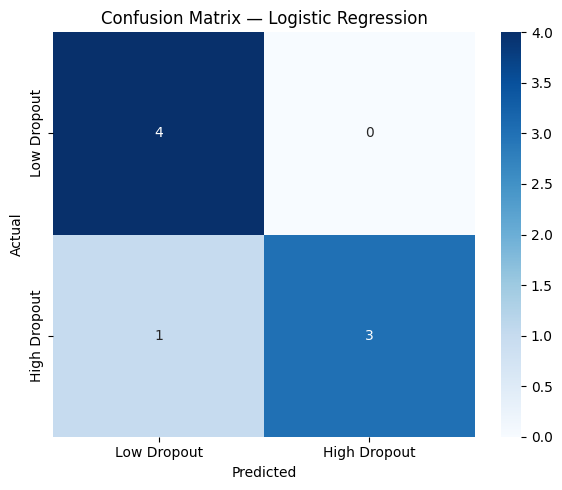

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Dropout", "High Dropout"],
    yticklabels=["Low Dropout", "High Dropout"],
)
plt.title("Confusion Matrix — Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_lr.png")
plt.show()

### Cross Validation

In [29]:
cv_scores = cross_val_score(lr, X, y, cv=5, scoring="f1")

print("5-Fold Cross Validation F1 Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold Cross Validation F1 Scores:
  Fold 1: 0.7500
  Fold 2: 1.0000
  Fold 3: 1.0000
  Fold 4: 0.6667
  Fold 5: 0.2857

Mean F1: 0.7405 (+/- 0.2635)


## Day 3 Summary
- Built Logistic Regression baseline model
- Approach: Predict Secondary dropout from Primary + Upper Primary rates
- Accuracy: 87.5% | F1: 85.7% | CV F1: 74% (more reliable with small dataset)
- No data leakage — features and target are independent
- Small dataset (37 states) causes variance in CV scores — expected
- Next: Decision Tree (Day 4)